In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score
import joblib
from joblib import Parallel, delayed
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import gc
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from catboost import CatBoostClassifier, Pool
import shap
from torch import Tensor
from typing import Tuple
import optuna
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import log_loss
import shap

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [2]:
import os

print("INPUT ROOT:", os.listdir("/kaggle/input"))

INPUT ROOT: ['combined_train.csv', 'combined_supplement.csv', 'combined_val.csv', 'combined_test.csv']


In [3]:
df = pd.read_csv("/kaggle/input/combined_train.csv")
print(df.shape)
df.head()

(2097168, 78)


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [4]:
df.isna().sum()

Protocol           0
Flow Duration      0
Tot Fwd Pkts       0
Tot Bwd Pkts       0
TotLen Fwd Pkts    0
                  ..
Idle Mean          0
Idle Std           0
Idle Max           0
Idle Min           0
Label              0
Length: 78, dtype: int64

In [5]:
X = df.drop(columns=['Label']).copy()
y = df['Label'].copy()

In [6]:
del df
gc.collect()

0

In [7]:
# one-hot encode Protocol
X = pd.get_dummies(
    X,
    columns=["Protocol"],
    prefix="Protocol",
    drop_first=False
)

# remove Protocol_0 column
X.drop(columns=["Protocol_0"], inplace=True, errors="ignore")

In [8]:
X.shape

(2097168, 78)

In [9]:
y = y.ravel() if y.ndim > 1 else y
le = LabelEncoder()
y = le.fit_transform(y)
joblib.dump(le, "/kaggle/working/label_encoder.joblib")

['/kaggle/working/label_encoder.joblib']

In [10]:
scaler = MinMaxScaler(feature_range=(0, 50))

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index)

min_max_mapping = pd.DataFrame({
    'column': X.columns,
    'min': scaler.data_min_,
    'max': scaler.data_max_
})
min_max_mapping.to_csv('/kaggle/working/column_min_max_mapping.csv', index=False)
print(f"Saved min/max mapping for {len(min_max_mapping)} columns")
min_max_mapping.head()

Saved min/max mapping for 78 columns


,column,min,max
0,Flow Duration,-9.190110e+11,120000000.0
1,Tot Fwd Pkts,0.000000e+00,9021.0
2,Tot Bwd Pkts,0.000000e+00,19181.0
3,TotLen Fwd Pkts,0.000000e+00,8737314.0
4,TotLen Bwd Pkts,0.000000e+00,27905234.0


# Checking Normality

In [11]:
def prepare_balanced_dataset(X_full, y_full, sample_size_per_class=5000, random_state=9):
    X_full = pd.DataFrame(X_full, columns=X_full.columns)
    y_full = pd.Series(y_full)

    classes = pd.unique(y_full)

    X_list = []
    y_list = []

    for cls in classes:
        cls_idx = y_full[y_full == cls].index
        sample_size = min(sample_size_per_class, len(cls_idx))
        cls_sample = cls_idx.to_series().sample(sample_size, random_state=random_state)
        X_list.append(X_full.loc[cls_sample])
        y_list.append(y_full.loc[cls_sample])

    sample_X = pd.concat(X_list, ignore_index=True)
    sample_y = pd.concat(y_list, ignore_index=True)

    return sample_X, sample_y, classes


sample_X, sample_y, classes = prepare_balanced_dataset(
    X,
    y,
    sample_size_per_class=5000
)

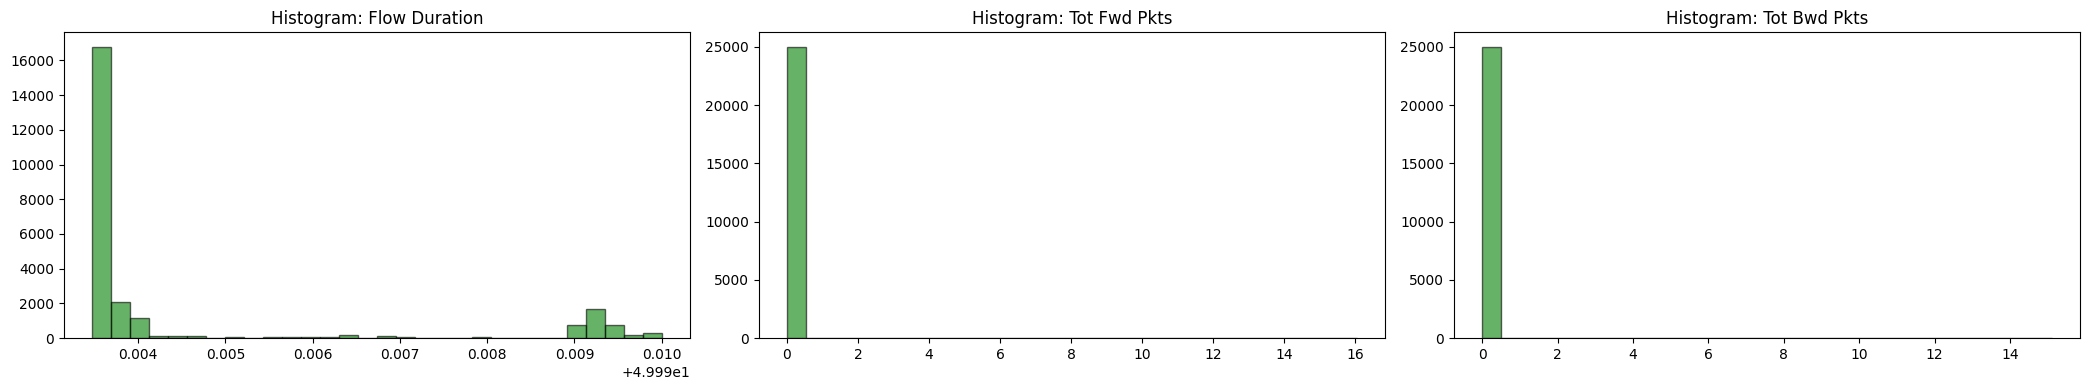

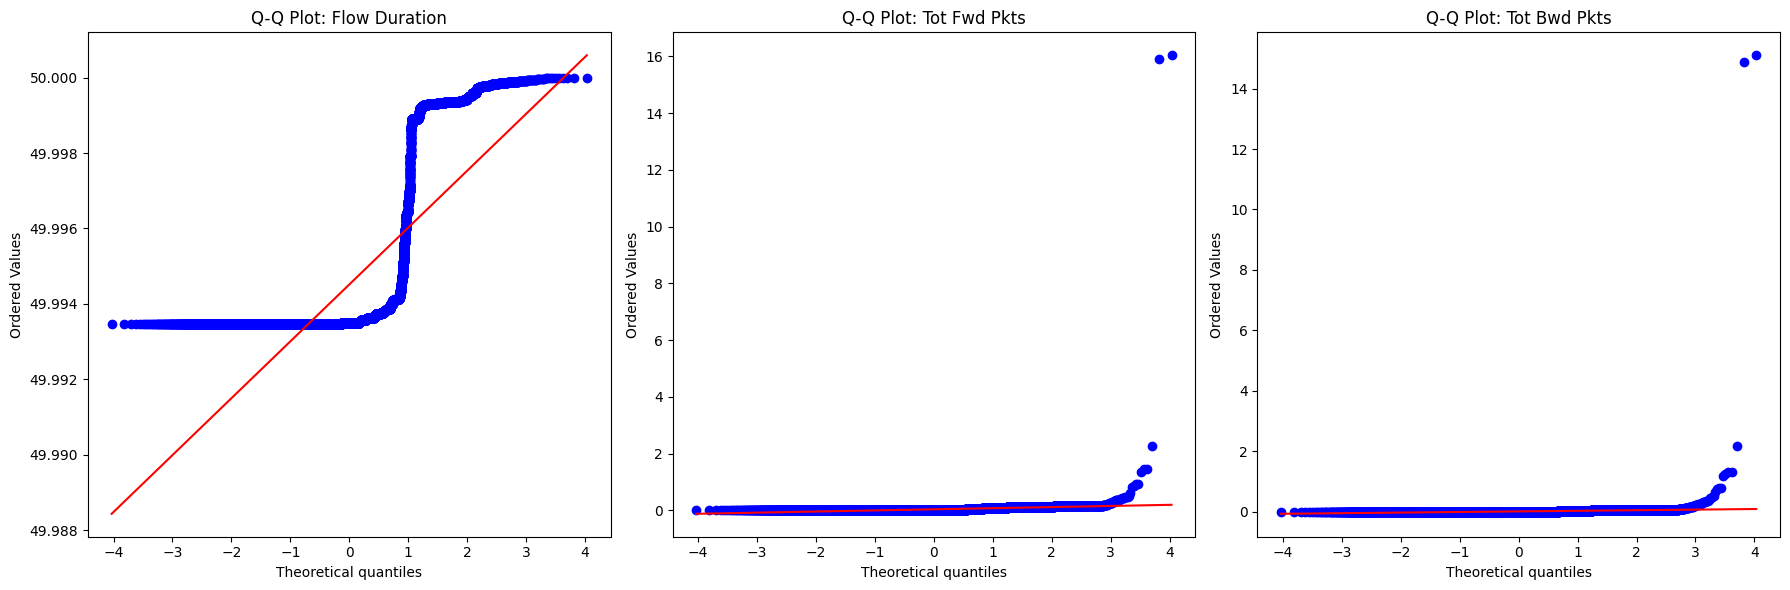

Normal columns (p ≥ 0.05): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Non-normal columns (p < 0.05): ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'ECE Flag Cnt', 'D

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25000.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [12]:
def check_normality(sample, plot_first=True, alpha=0.05, bins=30):
    normal_columns = []
    nonnormal_columns = []
    numeric_cols = sample.columns
    
    if plot_first:
        plot_cols = numeric_cols[:3]
        n_plots = len(plot_cols)
        
        if n_plots > 0:
            fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 4))
            if n_plots == 1:
                axes = [axes]
            
            for i, col in enumerate(plot_cols):
                data = sample[col].dropna()
                axes[i].hist(data, bins=bins, alpha=0.6, color='g', edgecolor='k')
                axes[i].set_title(f'Histogram: {col}')
            
            plt.tight_layout()
            plt.show()
            
            fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 6))
            if n_plots == 1:
                axes = [axes]
            
            for i, col in enumerate(plot_cols):
                data = sample[col].dropna()
                stats.probplot(data, dist="norm", plot=axes[i])
                axes[i].set_title(f'Q-Q Plot: {col}')
            
            plt.tight_layout()
            plt.show()
    
    for col in numeric_cols:
        data = sample[col].dropna()
        shapiro_stat, shapiro_p = stats.shapiro(data)
        if shapiro_p >= alpha:
            normal_columns.append(col)
        else:
            nonnormal_columns.append(col)
    
    print(f"Normal columns (p ≥ {alpha}):", normal_columns)
    print(f"Non-normal columns (p < {alpha}):", nonnormal_columns)

check_normality(sample_X)

# Catboost Feature Finding

In [13]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'MultiClass',
        'task_type': 'GPU',
        'devices': '0',
        'verbose': False,
        'random_state': 42
    }

    model = CatBoostClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model,
        sample_X,
        sample_y,
        cv=cv,
        scoring='neg_log_loss',
        n_jobs=1
    )

    return -scores.mean()


def get_top_features_optuna(sample_X, sample_y, n_trials=1, importance_threshold=0.95):
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({
        'loss_function': 'MultiClass',
        'task_type': 'GPU',
        'devices': '0',
        'verbose': False,
        'random_state': 42
    })

    model = CatBoostClassifier(**best_params)
    model.fit(sample_X, sample_y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(sample_X)

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean(
            [np.abs(sv) for sv in shap_values],
            axis=(0, 1)
        )
    else:
        mean_abs_shap = np.mean(
            np.abs(shap_values),
            axis=(0, 2)
        )

    importances = pd.DataFrame({
        'feature': sample_X.columns,
        'importance': mean_abs_shap
    }).sort_values(by='importance', ascending=False)

    threshold = importances['importance'].sum() * importance_threshold
    importances['cumsum'] = importances['importance'].cumsum()

    top_features = importances[
        importances['cumsum'] <= threshold
    ]['feature']

    return top_features.tolist(), model, study.best_params


top_features, best_model, best_params = get_top_features_optuna(
    sample_X,
    sample_y,
    n_trials=20
)

joblib.dump(top_features, '/kaggle/working/top_features.joblib')
print("Top features:", top_features)
print("Best parameters:", best_params)


[I 2026-01-03 08:10:25,358] A new study created in memory with name: no-name-68acdf33-cfee-4f62-a753-6bac94017207
[I 2026-01-03 08:10:52,375] Trial 0 finished with value: 0.03559576112525102 and parameters: {'iterations': 256, 'learning_rate': 0.014291191451364156, 'depth': 7, 'l2_leaf_reg': 6.048143488516258, 'border_count': 138}. Best is trial 0 with value: 0.03559576112525102.
[I 2026-01-03 08:11:10,978] Trial 1 finished with value: 0.01784816746168577 and parameters: {'iterations': 216, 'learning_rate': 0.023752653458263783, 'depth': 10, 'l2_leaf_reg': 6.563666199846689, 'border_count': 61}. Best is trial 1 with value: 0.01784816746168577.
[I 2026-01-03 08:11:59,738] Trial 2 finished with value: 0.0038257701599503095 and parameters: {'iterations': 981, 'learning_rate': 0.045741292676292164, 'depth': 9, 'l2_leaf_reg': 1.316347679459966, 'border_count': 93}. Best is trial 2 with value: 0.0038257701599503095.
[I 2026-01-03 08:12:14,859] Trial 3 finished with value: 0.00432786152148247

Top features: ['Fwd Pkts/s', 'Init Bwd Win Byts', 'Flow Pkts/s', 'Fwd Seg Size Min', 'Init Fwd Win Byts', 'Flow IAT Std', 'Pkt Len Max', 'ACK Flag Cnt', 'Fwd Header Len', 'Fwd Pkt Len Std', 'Bwd Pkts/s', 'Flow Byts/s', 'Fwd Pkt Len Max', 'Bwd Header Len', 'Fwd IAT Tot', 'Bwd Pkt Len Max', 'Fwd Pkt Len Mean', 'URG Flag Cnt', 'Fwd IAT Std', 'Pkt Len Std', 'Flow IAT Min', 'Flow IAT Mean', 'Down/Up Ratio']
Best parameters: {'iterations': 680, 'learning_rate': 0.04394602057917851, 'depth': 10, 'l2_leaf_reg': 1.1579164762779994, 'border_count': 95}


In [14]:
X = X[top_features]

gc.collect()

# Load and normalize validation data using training min/max
df_val = pd.read_csv("/kaggle/input/combined_val.csv")
X_val = df_val.drop(columns=['Label']).copy()

# One-hot encode Protocol
X_val = pd.get_dummies(X_val, columns=["Protocol"], prefix="Protocol", drop_first=False)
X_val.drop(columns=["Protocol_0"], inplace=True, errors="ignore")

# Select only top features
X_val = X_val[top_features]

# Normalize using training min/max
min_max_df = pd.read_csv('/kaggle/working/column_min_max_mapping.csv')
min_max_dict = {row['column']: (row['min'], row['max']) for _, row in min_max_df.iterrows()}
for col in X_val.columns:
    col_min, col_max = min_max_dict[col]
    if col_max - col_min != 0:
        X_val[col] = ((X_val[col] - col_min) / (col_max - col_min)) * 50
    else:
        X_val[col] = 0

print(f"Validation data shape: {X_val.shape}")

Validation data shape: (613113, 23)


# VAE Implmentation

In [15]:
# Prepare training data
X = X.values.astype(np.float64)
X = np.expand_dims(X, 1)
dataset = TensorDataset(torch.tensor(X, dtype=torch.float64))
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Prepare validation data
X_val = X_val.values.astype(np.float64)
X_val = np.expand_dims(X_val, 1)
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float64))
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)

n_features = X.shape[2]
latent_dim = 5

In [16]:
class Encoder(nn.Module):
    def __init__(
        self,
        n_features: int,
        latent_dim: int,
        conv_channels: int = 32,
        kernel_size: int = 10
    ):
        super().__init__()
        self.kernel_size = kernel_size
        self.conv1 = nn.Conv1d(
            in_channels=n_features,
            out_channels=conv_channels,
            kernel_size=kernel_size,
            padding=0
        ).double()
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=latent_dim,
            batch_first=True
        ).double()
        self.fc_mu = nn.Linear(latent_dim, latent_dim).double()
        self.fc_logvar = nn.Linear(latent_dim, latent_dim).double()

    def forward(self, x: Tensor) -> Tuple[Tensor, Tensor]:
        x = x.permute(0, 2, 1)
        x = F.pad(x, (self.kernel_size - 1, 0))
        x = self.relu(self.conv1(x))
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [17]:
class Decoder(nn.Module):
    def __init__(
        self,
        n_features: int,
        latent_dim: int,
        conv_channels: int = 32,
        kernel_size: int = 10
    ):
        super().__init__()
        self.kernel_size = kernel_size
        self.lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=conv_channels,
            batch_first=True
        ).double()
        self.deconv1 = nn.Conv1d(
            in_channels=conv_channels,
            out_channels=n_features,
            kernel_size=kernel_size,
            padding=0
        ).double()
        self.relu = nn.ReLU()

    def forward(self, z: Tensor) -> Tensor:
        x, _ = self.lstm(z)
        x = x.permute(0, 2, 1)
        x = F.pad(x, (self.kernel_size - 1, 0))
        x = self.deconv1(x)
        x = x.permute(0, 2, 1)
        return x

In [18]:
class VAE(nn.Module):
    def __init__(
        self,
        n_features: int,
        latent_dim: int,
        conv_channels: int = 32,
        kernel_size: int = 10
    ):
        super().__init__()
        self.encoder = Encoder(n_features, latent_dim, conv_channels, kernel_size)
        self.decoder = Decoder(n_features, latent_dim, conv_channels, kernel_size)

    def reparameterize(self, mu: Tensor, logvar: Tensor) -> Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

In [19]:
def student_t_loss(recon_x: Tensor, x: Tensor, df: float = 3.0) -> Tensor:
    diff = recon_x - x
    return torch.mean(torch.log1p((diff * diff) / df))

def vae_loss(
    recon_x: Tensor,
    x: Tensor,
    mu: Tensor,
    logvar: Tensor,
    beta: float = 0.5,
    df: float = 3.0
) -> Tuple[Tensor, Tensor]:
    
    recon_loss = student_t_loss(recon_x, x, df=df)
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta * kld, recon_loss

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_features = n_features
latent_dim = latent_dim
vae = VAE(n_features, latent_dim).double().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=3, T_mult=5, eta_min=1e-5)
epochs = 30
beta = 0.5
df = 3.0
vae.train()
all_recon_errors = []
all_latent_norms = []
for epoch in range(epochs):
    total_loss = 0.0
    total_samples = 0
    
    for batch in dataloader:
        x = batch[0].to(device)
        
        optimizer.zero_grad()
        
        recon_x, mu, logvar = vae(x)
        loss, recon_component = vae_loss(
            recon_x, x, mu, logvar, beta, df
        )
        
        loss.backward()
        optimizer.step()
        
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        
        with torch.no_grad():
            per_sample_recon = torch.mean((x - recon_x) ** 2, dim=(1, 2)).cpu().numpy()
            latent_flat = mu.view(mu.size(0), -1)
            per_sample_latent_norm = torch.norm(latent_flat, dim=1).cpu().numpy()
            
            all_recon_errors.append(per_sample_recon)
            all_latent_norms.append(per_sample_latent_norm)
            
    avg_loss = total_loss / total_samples
    
    # Compute validation loss
    vae.eval()
    val_loss = 0.0
    val_samples = 0
    with torch.no_grad():
        for batch in val_dataloader:
            x_val = batch[0].to(device)
            recon_x_val, mu_val, logvar_val = vae(x_val)
            loss_val, _ = vae_loss(recon_x_val, x_val, mu_val, logvar_val, beta, df)
            val_loss += loss_val.item() * x_val.size(0)
            val_samples += x_val.size(0)
    avg_val_loss = val_loss / val_samples
    vae.train()
    
    print(f"Epoch {epoch+1}/{epochs} Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    scheduler.step()
    print(f"Current Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    
all_recon_errors = np.concatenate(all_recon_errors, axis=0)
all_latent_norms = np.concatenate(all_latent_norms, axis=0)
np.save('reconstruction_errors.npy', all_recon_errors)
np.save('latent_norms.npy', all_latent_norms)

Epoch 1/30 Train Loss: 0.4966 | Val Loss: 0.3711
Current Learning Rate: 0.000753
Epoch 2/30 Train Loss: 0.4708 | Val Loss: 0.3710
Current Learning Rate: 0.000258
Epoch 3/30 Train Loss: 0.4708 | Val Loss: 0.3710
Current Learning Rate: 0.001000
Epoch 4/30 Train Loss: 0.4709 | Val Loss: 0.3711
Current Learning Rate: 0.000989
Epoch 5/30 Train Loss: 0.4709 | Val Loss: 0.3712
Current Learning Rate: 0.000957
Epoch 6/30 Train Loss: 0.4709 | Val Loss: 0.3710
Current Learning Rate: 0.000905
Epoch 7/30 Train Loss: 0.4709 | Val Loss: 0.3713
Current Learning Rate: 0.000836
Epoch 8/30 Train Loss: 0.4709 | Val Loss: 0.3709
Current Learning Rate: 0.000753
Epoch 9/30 Train Loss: 0.4708 | Val Loss: 0.3711
Current Learning Rate: 0.000658
Epoch 10/30 Train Loss: 0.4708 | Val Loss: 0.3711
Current Learning Rate: 0.000557
Epoch 11/30 Train Loss: 0.4708 | Val Loss: 0.3711
Current Learning Rate: 0.000453
Epoch 12/30 Train Loss: 0.4708 | Val Loss: 0.3715
Current Learning Rate: 0.000352
Epoch 13/30 Train Loss: 0

In [21]:
# Save the entire VAE model (architecture + weights)
torch.save(vae, "vae_full_model.pth")

In [22]:
vae = torch.load("vae_full_model.pth", weights_only=False)
vae.eval()

VAE(
  (encoder): Encoder(
    (conv1): Conv1d(23, 32, kernel_size=(10,), stride=(1,))
    (relu): ReLU()
    (lstm): LSTM(32, 5, batch_first=True)
    (fc_mu): Linear(in_features=5, out_features=5, bias=True)
    (fc_logvar): Linear(in_features=5, out_features=5, bias=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(5, 32, batch_first=True)
    (deconv1): Conv1d(32, 23, kernel_size=(10,), stride=(1,))
    (relu): ReLU()
  )
)

In [23]:
device = next(vae.encoder.parameters()).device
data_tensor = torch.tensor(X, dtype=torch.double).to(device)

batch_size = 256
n_samples = data_tensor.shape[0]
all_mu = []
all_recon_losses = []
all_kld_losses = []
df = 3.0

vae.eval()
with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        batch = data_tensor[i:i+batch_size]
        mu, logvar = vae.encoder(batch)
        all_mu.append(mu.squeeze(1).cpu())
        
        recon = vae.decoder(mu)
        diff = recon - batch
        per_row_recon = torch.log1p((diff * diff) / df).mean(dim=(1, 2))
        all_recon_losses.append(per_row_recon.cpu())
        
        per_row_kld = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean(dim=(1, 2))
        all_kld_losses.append(per_row_kld.cpu())

compressed_cpu = torch.cat(all_mu, dim=0).numpy()
recon_losses = torch.cat(all_recon_losses, dim=0).numpy()
kld_losses = torch.cat(all_kld_losses, dim=0).numpy()

compressed_X = pd.DataFrame(compressed_cpu, columns=[f'latent_{i}' for i in range(compressed_cpu.shape[1])])
compressed_X['recon_loss'] = recon_losses
compressed_X['kld_loss'] = kld_losses

del data_tensor, all_mu, all_recon_losses, all_kld_losses
gc.collect()

df_train = compressed_X.copy()
df_train['label'] = y
df_train.drop_duplicates(inplace=True)
df_train.reset_index(drop=True, inplace=True)

print(f"Compressed shape: {compressed_X.shape}")
print(f"df_train shape: {df_train.shape}")
df_train.head()

Compressed shape: (2097168, 7)
df_train shape: (1368907, 8)


,latent_0,latent_1,latent_2,latent_3,latent_4,recon_loss,kld_loss,label
0,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.148226,6.961641e-10,0
1,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.148240,6.961641e-10,0
2,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.148240,6.961641e-10,0
3,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.148240,6.961641e-10,0
4,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.731364,6.961641e-10,0


# Normality of compressed X 

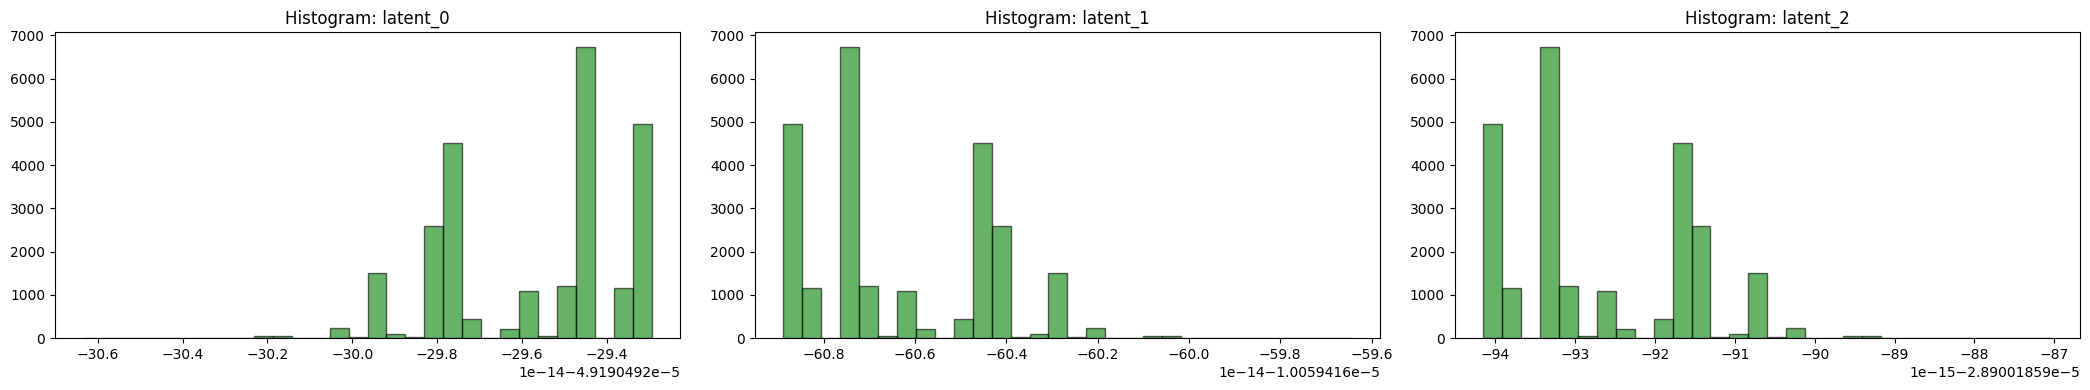

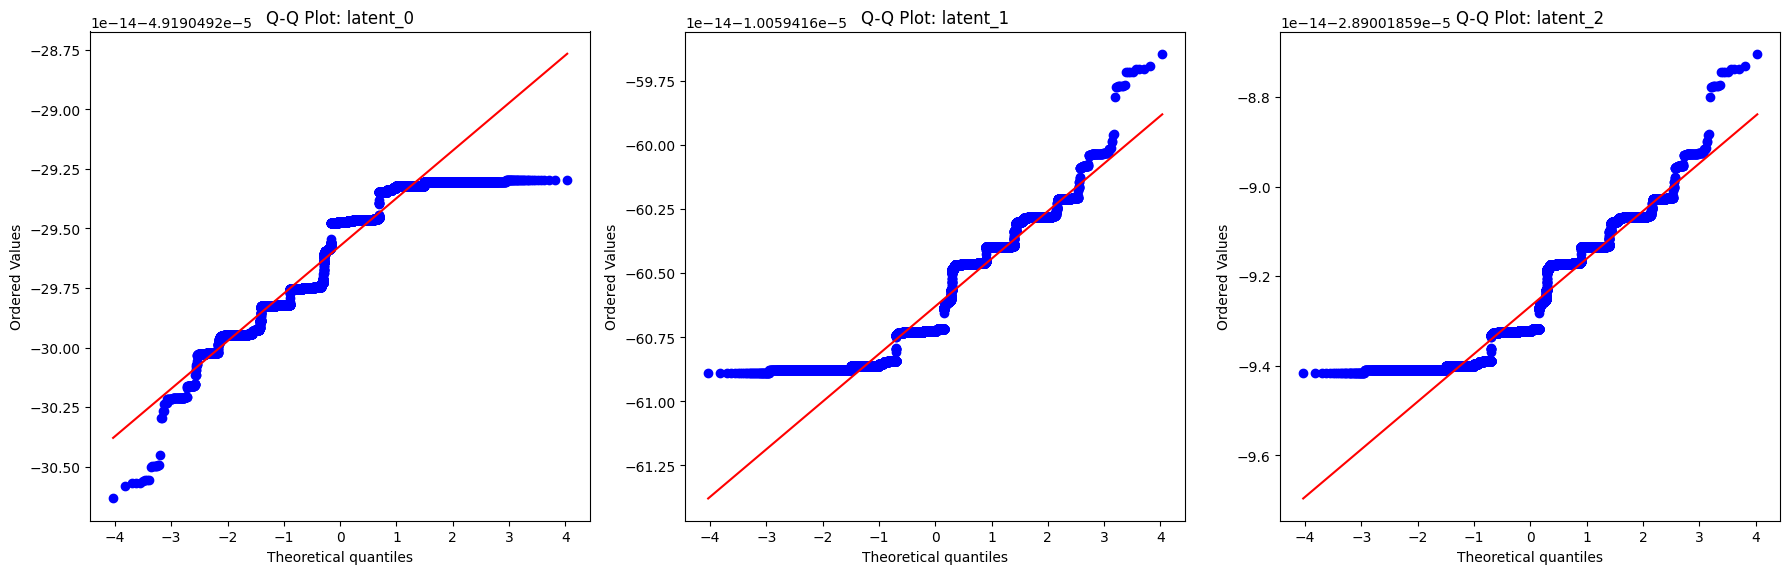

Normal columns (p ≥ 0.05): []
Non-normal columns (p < 0.05): ['latent_0', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'recon_loss', 'kld_loss']


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25000.
  res = hypotest_fun_out(*samples, **kwds)


In [24]:
sample_X, sample_y, classes = prepare_balanced_dataset(
    compressed_X,
    y,
    sample_size_per_class=5000
)
check_normality(sample_X)

# Pipeline

In [25]:
def inference_pipeline(X_new, y_new, vae_path, min_max_path, label_encoder_path, top_features_path, batch_size=2048):
    vae = torch.load(vae_path, weights_only=False)
    vae.eval()
    device = next(vae.encoder.parameters()).device
    
    min_max_df = pd.read_csv(min_max_path)
    min_max_dict = {row['column']: (row['min'], row['max']) for _, row in min_max_df.iterrows()}
    
    top_features = joblib.load(top_features_path)
    
    le = joblib.load(label_encoder_path)
    existing_classes = set(le.classes_)
    new_classes = set(y_new.unique()) - existing_classes
    
    if new_classes:
        extended_classes = np.concatenate([le.classes_, np.array(sorted(new_classes))])
        le.classes_ = extended_classes
    
    y_encoded = le.transform(y_new)
    
    X_new = pd.get_dummies(X_new, columns=["Protocol"], prefix="Protocol", drop_first=False)
    X_new.drop(columns=["Protocol_0"], inplace=True, errors="ignore")
    X_new = X_new[top_features]
    
    X_normalized = X_new.copy()
    for col in X_normalized.columns:
        col_min, col_max = min_max_dict[col]
        if col_max - col_min != 0:
            X_normalized[col] = ((X_new[col] - col_min) / (col_max - col_min)) * 50
        else:
            X_normalized[col] = 0
    
    X_array = X_normalized.values.astype(np.float64)
    X_array = np.expand_dims(X_array, 1)
    data_tensor = torch.tensor(X_array, dtype=torch.double).to(device)
    
    n_samples = data_tensor.shape[0]
    all_mu = []
    all_recon_losses = []
    all_kld_losses = []
    df = 3.0
    
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            batch = data_tensor[i:i+batch_size]
            mu, logvar = vae.encoder(batch)
            all_mu.append(mu.squeeze(1).cpu())
            
            recon = vae.decoder(mu)
            diff = recon - batch
            per_row_recon = torch.log1p((diff * diff) / df).mean(dim=(1, 2))
            all_recon_losses.append(per_row_recon.cpu())
            
            per_row_kld = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean(dim=(1, 2))
            all_kld_losses.append(per_row_kld.cpu())
    
    compressed_cpu = torch.cat(all_mu, dim=0).numpy()
    recon_losses = torch.cat(all_recon_losses, dim=0).numpy()
    kld_losses = torch.cat(all_kld_losses, dim=0).numpy()
    
    compressed_X = pd.DataFrame(compressed_cpu, columns=[f'latent_{i}' for i in range(compressed_cpu.shape[1])])
    compressed_X['recon_loss'] = recon_losses
    compressed_X['kld_loss'] = kld_losses
    
    df_sup = compressed_X.copy()
    df_sup['label'] = y_encoded
    df_sup.drop_duplicates(inplace=True)
    df_sup.reset_index(drop=True, inplace=True)
    
    joblib.dump(le, label_encoder_path)
    
    del data_tensor, all_mu, all_recon_losses, all_kld_losses
    gc.collect()

    return df_sup, le

In [26]:
df_new = pd.read_csv("/kaggle/input/combined_supplement.csv")
df_sup, updated_le = inference_pipeline(
    X_new=df_new.drop(columns=['Label']),
    y_new=df_new['Label'],
    vae_path="vae_full_model.pth",
    min_max_path="/kaggle/working/column_min_max_mapping.csv",
    label_encoder_path="/kaggle/working/label_encoder.joblib",
    top_features_path="/kaggle/working/top_features.joblib"
)
print(f"df_sup shape: {df_sup.shape}")
df_sup.head()

df_sup shape: (833817, 8)


,latent_0,latent_1,latent_2,latent_3,latent_4,recon_loss,kld_loss,label
0,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.148226,6.961641e-10,0
1,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.659607,6.961641e-10,0
2,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.042854,6.961641e-10,0
3,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.042854,6.961641e-10,0
4,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.659608,6.961641e-10,0


# 1 vs all class

In [27]:
# Create binary labels: 0 stays 0, everything else becomes 1 (attack)
df_sup_binary = df_sup.copy()
df_sup_binary['binary_label'] = (df_sup_binary['label'] != 0).astype(int)

print(f"Class distribution:")
print(f"  Benign (0): {(df_sup_binary['binary_label'] == 0).sum()}")
print(f"  Attack (1): {(df_sup_binary['binary_label'] == 1).sum()}")

# Get loss stats for each class
benign_mask = df_sup_binary['binary_label'] == 0
attack_mask = df_sup_binary['binary_label'] == 1

print("\n" + "="*50)
print("Loss Statistics:")
print("="*50)
print(f"\nBenign (label=0):")
print(f"  recon_loss - mean: {df_sup_binary.loc[benign_mask, 'recon_loss'].mean():.6f}, max: {df_sup_binary.loc[benign_mask, 'recon_loss'].max():.6f}")
print(f"  kld_loss   - mean: {df_sup_binary.loc[benign_mask, 'kld_loss'].mean():.6f}, max: {df_sup_binary.loc[benign_mask, 'kld_loss'].max():.6f}")

print(f"\nAttack (label!=0):")
print(f"  recon_loss - mean: {df_sup_binary.loc[attack_mask, 'recon_loss'].mean():.6f}, min: {df_sup_binary.loc[attack_mask, 'recon_loss'].min():.6f}")
print(f"  kld_loss   - mean: {df_sup_binary.loc[attack_mask, 'kld_loss'].mean():.6f}, min: {df_sup_binary.loc[attack_mask, 'kld_loss'].min():.6f}")

Class distribution:
  Benign (0): 833274
  Attack (1): 543

Loss Statistics:

Benign (label=0):
  recon_loss - mean: 0.448344, max: 1.706019
  kld_loss   - mean: 0.000000, max: 0.000000

Attack (label!=0):
  recon_loss - mean: 0.387227, min: 0.042850
  kld_loss   - mean: 0.000000, min: 0.000000


In [28]:
# Grid search for best thresholds - MAXIMIZE WEIGHTED F1 (GPU accelerated, float64)
# AND condition: predict attack if BOTH losses are above thresholds
# Class weights: inverse frequency to give equal importance to both classes
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

recon_vals = torch.tensor(df_sup_binary['recon_loss'].values, dtype=torch.float64, device=device)
kld_vals = torch.tensor(df_sup_binary['kld_loss'].values, dtype=torch.float64, device=device)
y_true_t = torch.tensor(df_sup_binary['binary_label'].values, dtype=torch.float64, device=device)

# Compute class weights (inverse frequency)
n_total = len(y_true_t)
n_benign = (y_true_t == 0).sum().item()
n_attack = (y_true_t == 1).sum().item()
weight_benign = n_total / (2 * n_benign)
weight_attack = n_total / (2 * n_attack)
print(f"Class weights - Benign: {weight_benign:.4f}, Attack: {weight_attack:.4f}")

recon_thresholds = torch.linspace(recon_vals.min().item(), recon_vals.max().item(), 100, device=device)
kld_thresholds = torch.linspace(kld_vals.min().item(), kld_vals.max().item(), 100, device=device)

best_weighted_f1 = 0
best_recon_thresh = 0
best_kld_thresh = 0

for recon_thresh in recon_thresholds:
    for kld_thresh in kld_thresholds:
        # AND condition: both must exceed thresholds
        y_pred = ((recon_vals > recon_thresh) & (kld_vals > kld_thresh)).float()
        
        tp = ((y_pred == 1) & (y_true_t == 1)).sum().item()
        fp = ((y_pred == 1) & (y_true_t == 0)).sum().item()
        tn = ((y_pred == 0) & (y_true_t == 0)).sum().item()
        fn = ((y_pred == 0) & (y_true_t == 1)).sum().item()
        
        # Weighted precision and recall
        # Precision for attack class (weighted by attack weight)
        precision_attack = tp / (tp + fp) if (tp + fp) > 0 else 0
        # Recall for attack class (weighted by attack weight)
        recall_attack = tp / (tp + fn) if (tp + fn) > 0 else 0
        # F1 for attack class
        f1_attack = 2 * precision_attack * recall_attack / (precision_attack + recall_attack) if (precision_attack + recall_attack) > 0 else 0
        
        # Precision for benign class
        precision_benign = tn / (tn + fn) if (tn + fn) > 0 else 0
        # Recall for benign class
        recall_benign = tn / (tn + fp) if (tn + fp) > 0 else 0
        # F1 for benign class
        f1_benign = 2 * precision_benign * recall_benign / (precision_benign + recall_benign) if (precision_benign + recall_benign) > 0 else 0
        
        # Weighted average F1 (equal weight to both classes)
        weighted_f1 = (weight_benign * f1_benign + weight_attack * f1_attack) / (weight_benign + weight_attack)
        
        if weighted_f1 > best_weighted_f1:
            best_weighted_f1 = weighted_f1
            best_recon_thresh = recon_thresh.item()
            best_kld_thresh = kld_thresh.item()

# Compute final metrics with AND condition
y_pred_final = ((recon_vals > best_recon_thresh) & (kld_vals > best_kld_thresh)).float()
tp = ((y_pred_final == 1) & (y_true_t == 1)).sum().item()
fp = ((y_pred_final == 1) & (y_true_t == 0)).sum().item()
tn = ((y_pred_final == 0) & (y_true_t == 0)).sum().item()
fn = ((y_pred_final == 0) & (y_true_t == 1)).sum().item()

precision_attack = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_attack = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_attack = 2 * precision_attack * recall_attack / (precision_attack + recall_attack) if (precision_attack + recall_attack) > 0 else 0

precision_benign = tn / (tn + fn) if (tn + fn) > 0 else 0
recall_benign = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_benign = 2 * precision_benign * recall_benign / (precision_benign + recall_benign) if (precision_benign + recall_benign) > 0 else 0

weighted_f1 = (weight_benign * f1_benign + weight_attack * f1_attack) / (weight_benign + weight_attack)

best_metrics = {
    'weighted_f1': weighted_f1,
    'f1_attack': f1_attack, 'precision_attack': precision_attack, 'recall_attack': recall_attack,
    'f1_benign': f1_benign, 'precision_benign': precision_benign, 'recall_benign': recall_benign
}

print("="*50)
print("BEST THRESHOLDS (AND condition) - MAX WEIGHTED F1:")
print("="*50)
print(f"recon_loss threshold: {best_recon_thresh}")
print(f"kld_loss threshold:   {best_kld_thresh}")
print(f"\nWeighted F1 Score:    {best_metrics['weighted_f1']:.4f}  <- maximized (equal class weight)")
print(f"\nAttack class metrics:")
print(f"  F1:        {best_metrics['f1_attack']:.4f}")
print(f"  Precision: {best_metrics['precision_attack']:.4f}")
print(f"  Recall:    {best_metrics['recall_attack']:.4f}")
print(f"\nBenign class metrics:")
print(f"  F1:        {best_metrics['f1_benign']:.4f}")
print(f"  Precision: {best_metrics['precision_benign']:.4f}")
print(f"  Recall:    {best_metrics['recall_benign']:.4f}")

# Save thresholds
thresholds = {
    'recon_loss_threshold': best_recon_thresh,
    'kld_loss_threshold': best_kld_thresh,
    'weighted_f1': best_metrics['weighted_f1'],
    'f1_attack': best_metrics['f1_attack'],
    'f1_benign': best_metrics['f1_benign']
}
joblib.dump(thresholds, '/kaggle/working/anomaly_thresholds.joblib')
print(f"\nThresholds saved to /kaggle/working/anomaly_thresholds.joblib")

Class weights - Benign: 0.5003, Attack: 767.7873
BEST THRESHOLDS (AND condition) - MAX WEIGHTED F1:
recon_loss threshold: 0.45699337124824524
kld_loss threshold:   6.961641263458773e-10

Weighted F1 Score:    0.0055  <- maximized (equal class weight)

Attack class metrics:
  F1:        0.0048
  Precision: 0.0024
  Recall:    0.2836

Benign class metrics:
  F1:        0.9605
  Precision: 0.9995
  Recall:    0.9245

Thresholds saved to /kaggle/working/anomaly_thresholds.joblib


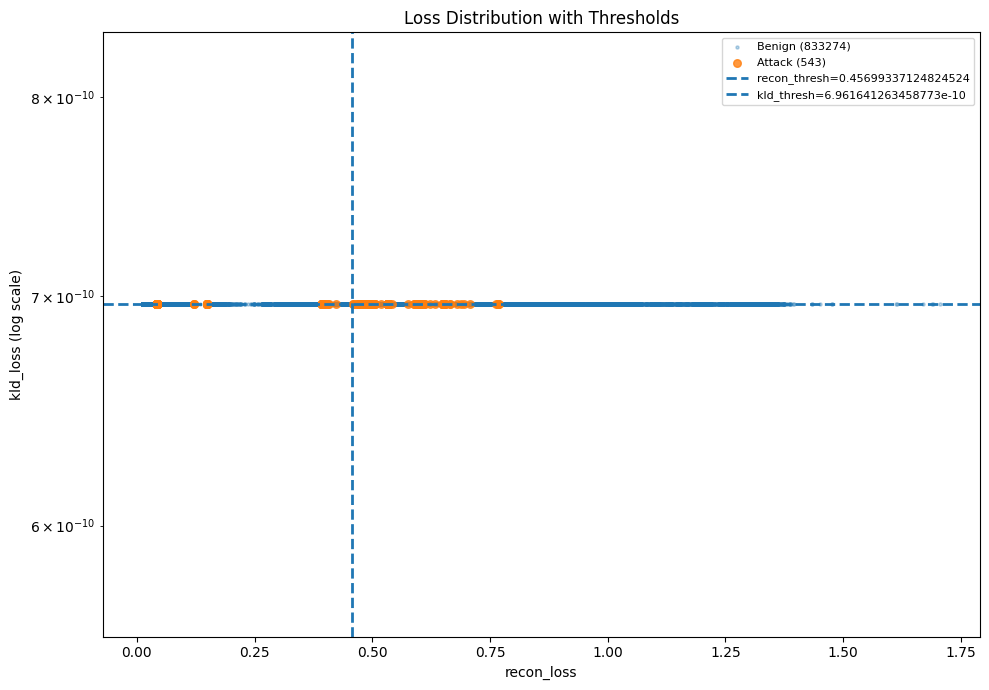


Decision Rule: Predict ATTACK if (recon_loss > 0.45699337124824524) AND (kld_loss > 6.961641263458773e-10)


In [29]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot benign first (background)
benign = df_sup_binary[df_sup_binary['binary_label'] == 0]
ax.scatter(
    benign['recon_loss'],
    benign['kld_loss'],
    alpha=0.3,
    s=5,
    label=f'Benign ({len(benign)})'
)

# Plot attacks on top (foreground)
attack = df_sup_binary[df_sup_binary['binary_label'] == 1]
ax.scatter(
    attack['recon_loss'],
    attack['kld_loss'],
    alpha=0.8,
    s=30,
    label=f'Attack ({len(attack)})'
)

# Threshold lines
ax.axvline(
    x=best_recon_thresh,
    linestyle='--',
    linewidth=2,
    label=f'recon_thresh={best_recon_thresh}'
)

ax.axhline(
    y=best_kld_thresh,
    linestyle='--',
    linewidth=2,
    label=f'kld_thresh={best_kld_thresh}'
)

# ---- Dynamic scaling ----

# X axis (linear, padded)
recon_min = df_sup_binary['recon_loss'].min()
recon_max = df_sup_binary['recon_loss'].max()
recon_pad = (recon_max - recon_min) * 0.05
ax.set_xlim(recon_min - recon_pad, recon_max + recon_pad)

# Y axis (log-scale for very small KLD values)
ax.set_yscale('log')

kld_min = df_sup_binary['kld_loss'][df_sup_binary['kld_loss'] > 0].min()
kld_max = df_sup_binary['kld_loss'].max()
ax.set_ylim(kld_min * 0.8, kld_max * 1.2)

# Labels & layout
ax.set_xlabel('recon_loss')
ax.set_ylabel('kld_loss (log scale)')
ax.set_title('Loss Distribution with Thresholds')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print(
    f"\nDecision Rule: Predict ATTACK if "
    f"(recon_loss > {best_recon_thresh}) "
    f"AND (kld_loss > {best_kld_thresh})"
)


# Saving train and test

In [30]:
# Save df_train
df_train.to_csv('/kaggle/working/df_train.csv', index=False)
print(f"df_train saved to /kaggle/working/df_train.csv (shape: {df_train.shape})")

df_train saved to /kaggle/working/df_train.csv (shape: (1368907, 8))


In [31]:

df_test_raw = pd.read_csv("/kaggle/input/combined_test.csv") 
df_test, updated_le = inference_pipeline(
    X_new=df_test_raw.drop(columns=['Label']),
    y_new=df_test_raw['Label'],
    vae_path="vae_full_model.pth",
    min_max_path="/kaggle/working/column_min_max_mapping.csv",
    label_encoder_path="/kaggle/working/label_encoder.joblib",
    top_features_path="/kaggle/working/top_features.joblib"
)

df_test.to_csv('/kaggle/working/df_test.csv', index=False)
print(f"df_test saved to /kaggle/working/df_test.csv (shape: {df_test.shape})")
df_test.head()

df_test saved to /kaggle/working/df_test.csv (shape: (560133, 8))


,latent_0,latent_1,latent_2,latent_3,latent_4,recon_loss,kld_loss,label
0,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.148226,6.961641e-10,0
1,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.467340,6.961641e-10,0
2,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.042854,6.961641e-10,0
3,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.042851,6.961641e-10,0
4,-0.000049,-0.00001,-0.000029,0.000022,0.000001,0.042851,6.961641e-10,0
